In [13]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
#| output: false
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-cpu==2.21.0 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow-cpu==2.21.0


# 📊 Étape 3 : Visualisation Multidimensionnelle

Visualiser les relations entre variables pour dégager des insights actionnables et valider nos hypothèses avant modélisation.

### 1. Préparation de l'environnement

In [14]:
#| output: true
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src import data_clean as dc
from src import utils_viz as uv

uv.set_custom_style(theme='light')
%matplotlib inline
print("Librairies de visualisation prêtes !")

Style 'light' activé 
Librairies de visualisation prêtes !


### 2. Chargement du dataset enrichi

In [15]:
df = pd.read_csv('../data/processed/dataset_clean.csv')
df['duration_min'] = df['duration_ms'] / 60000 
df_feat = df.copy()
df_feat['is_popular'] = (df_feat['popularity'] >= 50).astype(int)  # chanson populaire ou non
df_feat['is_long'] = (df_feat['duration_min'] >= 4).astype(int)    # chanson longue ou non
#| output: false
df_feat.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,valence,tempo,time_signature,track_genre,genre_family,genre_family_name,is_hit,duration_min,is_popular,is_long
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0.715,87.917,4,acoustic,2,Acoustique / Singer-Songwriter,1,3.844433,1,0
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,0.267,77.489,4,acoustic,2,Acoustique / Singer-Songwriter,1,2.493500,1,0
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,0.120,76.332,4,acoustic,2,Acoustique / Singer-Songwriter,1,3.513767,1,0
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,0.143,181.740,3,acoustic,2,Acoustique / Singer-Songwriter,1,3.365550,1,0
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,0.167,119.949,4,acoustic,2,Acoustique / Singer-Songwriter,1,3.314217,1,0


### 3. Tracés et analyses graphiques

#### A. Popularité par genre

Pop, Film et R&B dominent. Le genre crée un avantage structurel algorithmique indépendant du son — ce qui motive notre approche de rang relatif *dans* le genre plutôt qu'absolu.

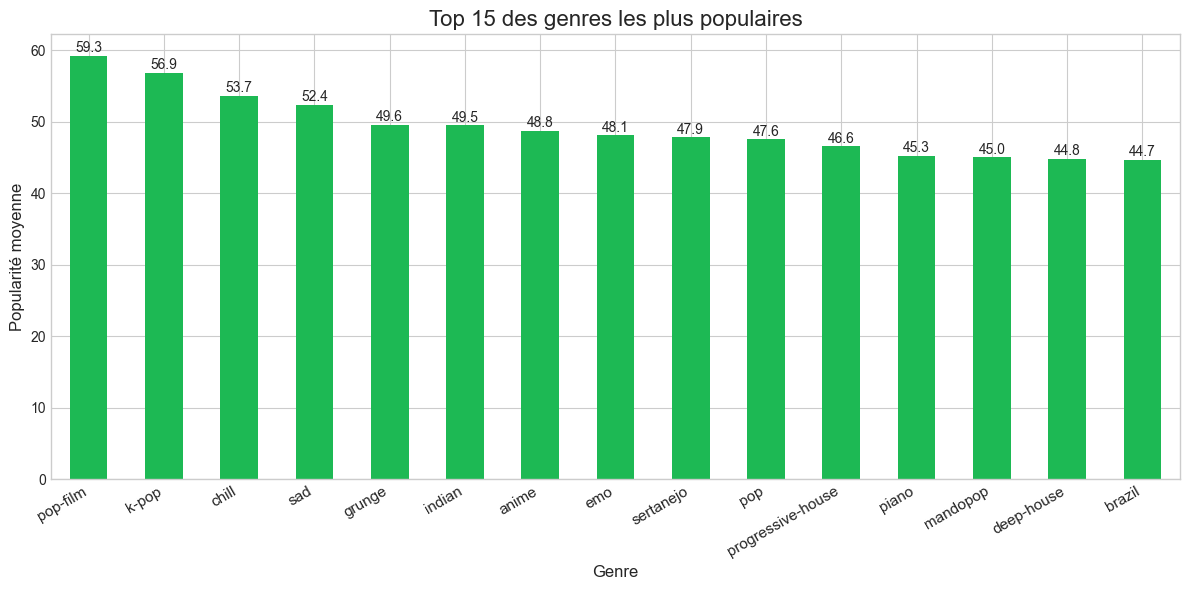

In [16]:
#| output: true
fig, ax = plt.subplots(figsize=(12, 6))

# Garder seulement les 15 genres les plus populaires
top15 = df_feat.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(15)

top15.plot(kind='bar', color='#1DB954', ax=ax)

ax.set_title("Top 15 des genres les plus populaires", fontsize=16)
ax.set_xlabel("Genre", fontsize=12)
ax.set_ylabel("Popularité moyenne", fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=11)

# Ajouter les valeurs sur chaque barre
for i, v in enumerate(top15):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### B. Heatmap des corrélations

`energy ↔ loudness` (r=0.76) et `energy ↔ acousticness` (r=-0.73) sont attendus. Ce qui compte : **aucune feature audio ne dépasse r=0.07 avec la popularité** — confirme que l'audio seul ne prédit pas le succès.

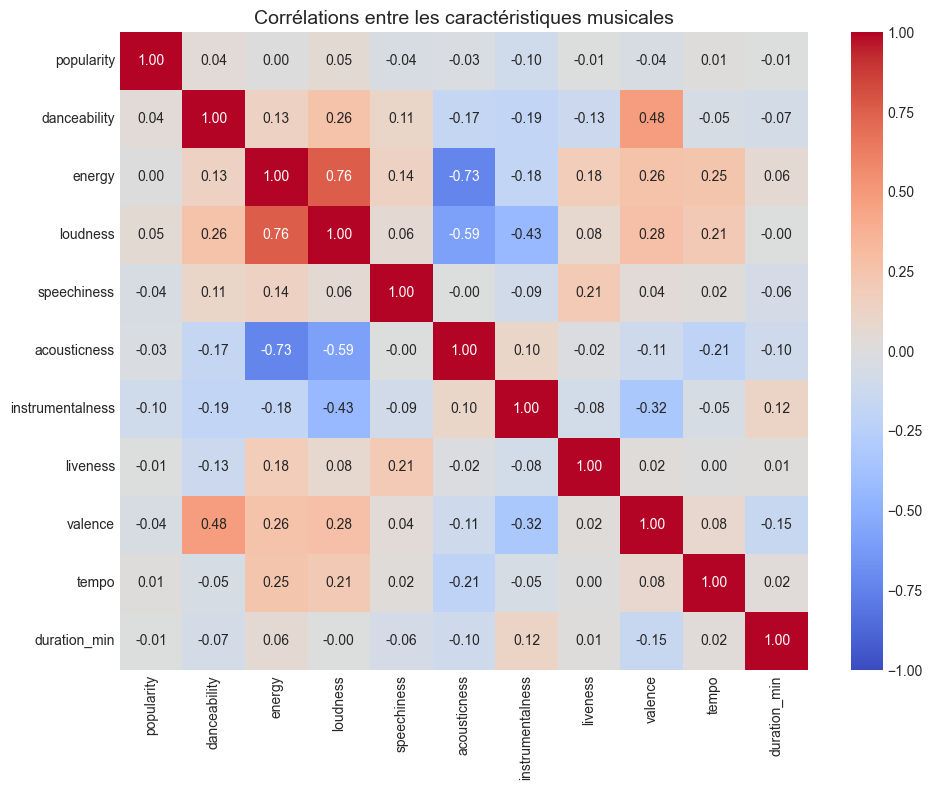

In [17]:
#| output: true
colonnes_correlation = [
    'popularity', 
    'danceability', 
    'energy', 
    'loudness', 
    'speechiness', 
    'acousticness', 
    'instrumentalness', 
    'liveness', 
    'valence', 
    'tempo',
    'duration_min'
]

# Appeler la fonction
uv.plot_correlation_matrix(
    df_feat, 
    colonnes_correlation,
    title="Corrélations entre les caractéristiques musicales"
)
plt.show()

#### C. Dansabilité vs Popularité

Dispersion totale : un morceau très dansant peut avoir une popularité proche de zéro. Valide visuellement que la dansabilité n'est pas un prédicteur fiable du succès.

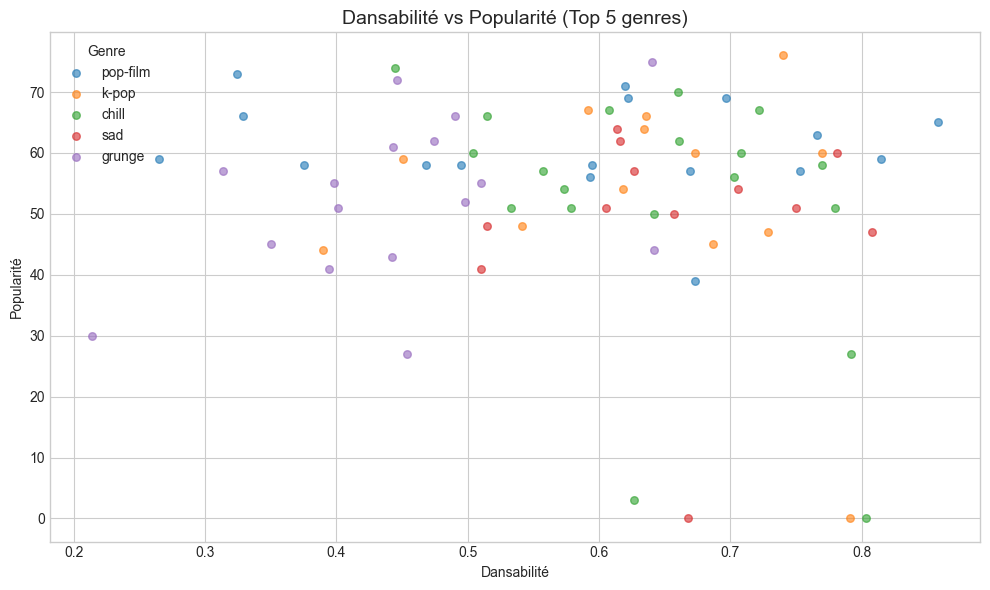

In [18]:
#| output: true
# Nuage de points : danceability vs popularity coloré par genre
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Prendre seulement 2000 chansons au hasard pour que ce soit lisible
df_sample = df_feat.sample(2000, random_state=42)

# Colorer par genre (top 5 seulement)
top5_genres = df_feat.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(5).index

df_sample_top = df_sample[df_sample['track_genre'].isin(top5_genres)]

for genre in top5_genres:
    subset = df_sample_top[df_sample_top['track_genre'] == genre]
    ax.scatter(subset['danceability'], subset['popularity'], 
               label=genre, alpha=0.6, s=30)

ax.set_title("Dansabilité vs Popularité (Top 5 genres)", fontsize=14)
ax.set_xlabel("Dansabilité")
ax.set_ylabel("Popularité")
ax.legend(title="Genre")
plt.tight_layout()
plt.show()

### 4. Rang relatif par Famille Musicale

Au lieu de comparer des popularités brutes entre genres (un hit de Classique ≠ un hit de Pop), on visualise le **rang percentile dans le genre**. Chaque point représente où se situe un morceau par rapport à la compétition de son propre genre — c'est exactement la cible du modèle unifié.

C:\Users\jacqu\AppData\Local\Temp\ipykernel_58436\2978242845.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='genre_family_name', y='pop_rank_in_genre',


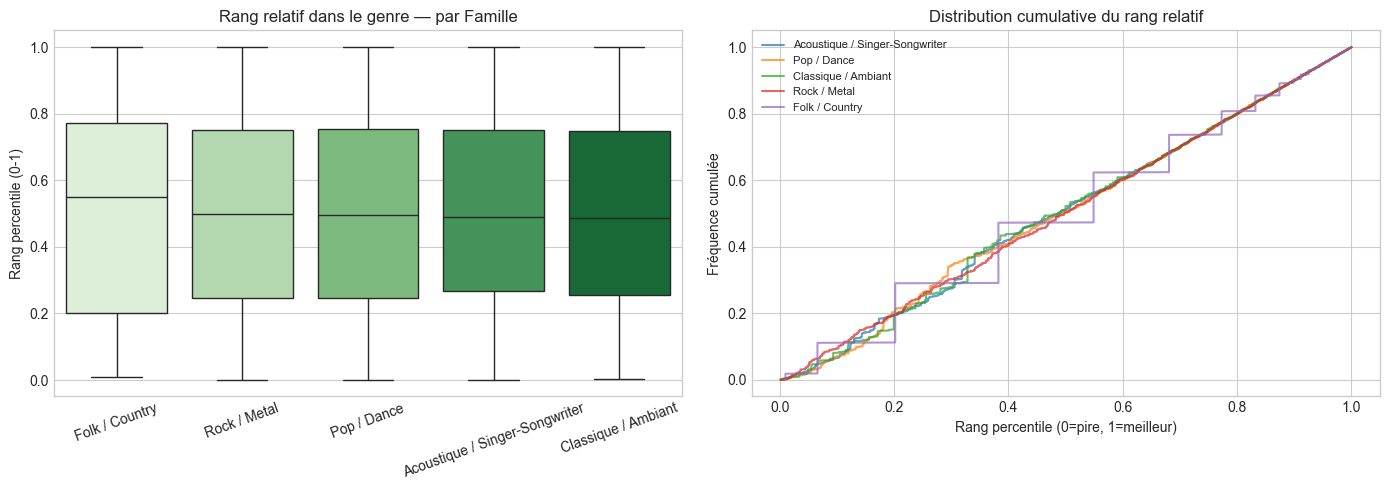

→ La distribution est quasi-uniforme dans chaque genre : le rang relatif est bien normalisé.


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_feat.dropna(subset=['genre_family_name']).copy()

# Rang percentile dans le genre (0=pire, 1=meilleur) — la cible du modèle
df_plot['pop_rank_in_genre'] = df_plot.groupby('track_genre')['popularity'].transform(
    lambda x: x.rank(pct=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot du rang relatif par famille
order = df_plot.groupby('genre_family_name')['pop_rank_in_genre'].median().sort_values(ascending=False).index
sns.boxplot(data=df_plot, x='genre_family_name', y='pop_rank_in_genre',
            order=order, palette='Greens', ax=axes[0])
axes[0].set_title("Rang relatif dans le genre — par Famille", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Rang percentile (0-1)")
axes[0].tick_params(axis='x', rotation=20)

# Distribution du rang relatif par famille (KDE)
for fam in df_plot['genre_family_name'].unique():
    sub = df_plot[df_plot['genre_family_name'] == fam]['pop_rank_in_genre']
    axes[1].plot(sorted(sub), [i/len(sub) for i in range(len(sub))], label=fam, alpha=0.7)
axes[1].set_title("Distribution cumulative du rang relatif", fontsize=12)
axes[1].set_xlabel("Rang percentile (0=pire, 1=meilleur)")
axes[1].set_ylabel("Fréquence cumulée")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("→ La distribution est quasi-uniforme dans chaque genre : le rang relatif est bien normalisé.")